In [1]:
# Check for GPU
!nvidia-smi

Wed May 20 10:47:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.49                 Driver Version: 596.49         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   28C    P8              7W /  320W |     975MiB /  16376MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device
     

2.5.1


'cuda'

In [3]:
##1. What are 3 areas in industry where computer vision is currently being used?

## Manufactoring, Retail, Healthcare

In [4]:
## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

## overfittin means that models doenst generalise well, meaning it remembers specific details of train data and doesnt perform well on test data

## simplify model, remove layers, get more data, regulization

In [5]:
import torchvision 

MnistTrain = torchvision.datasets.MNIST(
    root="~/Handwritten_Deep_L/",
    train=True,
    download=True,
    transform=torchvision.transforms.Compose([torchvision.transforms.ToTensor()]),
)

In [6]:
MnistTest = torchvision.datasets.MNIST(
    root="~/Handwritten_Deep_L/",
    train=False,
    download=True,
    transform=torchvision.transforms.Compose([torchvision.transforms.ToTensor()]),
)

In [7]:
len(MnistTest)

10000

In [8]:
len(MnistTrain)

60000

In [9]:
image, label = MnistTrain[0]

print(image.shape)

torch.Size([1, 28, 28])


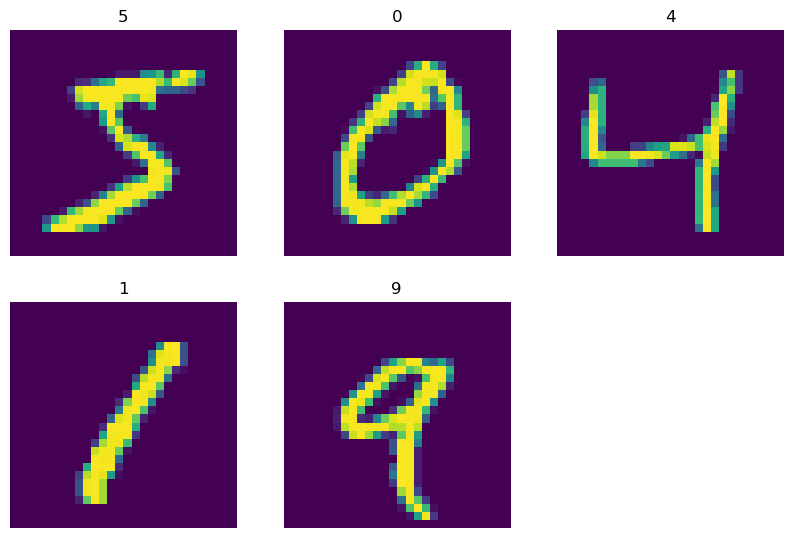

In [26]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))

for i in range(5):
    image, label = MnistTrain[i]
    plt.subplot(3, 3, i + 1)
    plt.imshow(image.squeeze())
    plt.axis('off')  # Hide the axis labels
    plt.title(label)


In [92]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(MnistTrain, batch_size=32, shuffle=False)
test_dataloader = DataLoader(MnistTest, batch_size=32, shuffle=False)

In [93]:
from torch import nn

class NumbersModel(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block1 = nn.Sequential(
          nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block1(x)
        # print(x.shape)
        x = self.block2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

In [94]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [95]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [96]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

class_names = MnistTrain.classes

In [97]:
torch.manual_seed(42)
NM = NumbersModel(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to(device)
NM

NumbersModel(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [98]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=NM.parameters(), 
                            lr=0.1)

In [99]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=NM, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
        model=NM,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.26405 | Train accuracy: 91.30%
Test loss: 0.08931 | Test accuracy: 97.15%

Epoch: 1
---------
Train loss: 0.06896 | Train accuracy: 97.89%
Test loss: 0.06840 | Test accuracy: 97.81%

Epoch: 2
---------
Train loss: 0.05360 | Train accuracy: 98.38%
Test loss: 0.05468 | Test accuracy: 98.25%

Train time on cuda: 18.795 seconds


In [100]:
NM.eval()

count = len(MnistTest)
result_np = []

with torch.inference_mode():
    for i in range(0, count):
        # Get image + label
        image, label = MnistTest[i]

         # Move image to device and add batch dimension
        image_for_model = image.unsqueeze(0).to(device)
        
        # Make prediction
        pred = NM(image_for_model)
        pred_np = pred.cpu().detach().numpy()
        # Convert logits -> predicted class
        pred_label = torch.argmax(logits, dim=1).item()
        for elem in pred_np:
            result_np.append(elem)


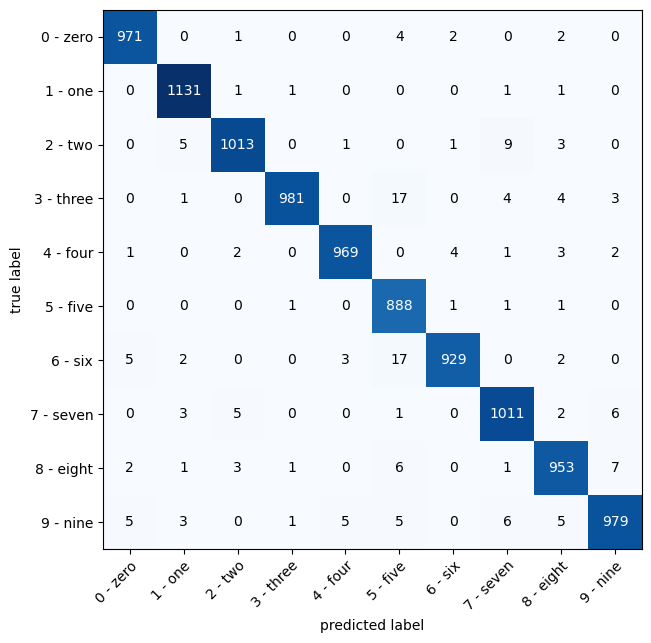

In [101]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
import torch

# Put model in evaluation mode
NM.eval()

# Store predictions
y_preds = []

with torch.inference_mode():
    for X, y in test_dataloader:

        # Move data to device
        X = X.to(device)

        # Forward pass
        y_logits = NM(X)

        # Convert logits -> prediction labels
        y_pred = torch.argmax(y_logits, dim=1)

        # Move predictions back to CPU
        y_preds.append(y_pred.cpu())

# Combine all batches into one tensor
y_pred_tensor = torch.cat(y_preds)

# Create confusion matrix object
confmat = ConfusionMatrix(
    task="multiclass",
    num_classes=len(class_names)
)

# Generate confusion matrix tensor
confmat_tensor = confmat(
    preds=y_pred_tensor,
    target=MnistTest.targets
)

# Plot
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

plt.show()